# Author: Dr Partha Majumdar
## ORC-ID: 0009-0002-7375-8034

# Step 1: Install the required libraries

In [1]:
# Install only if needed
# !pip install -qq fasttext==0.9.3 tensorflow-datasets==4.9.9

In [2]:
import importlib.metadata as im

for pkg in [
    "fasttext", "tensorflow-datasets"
]:
    print(pkg, "==", im.version(pkg))

fasttext == 0.9.3
tensorflow-datasets == 4.9.9


# Step 2: Import the required libraries

In [3]:
import re
import os
import fasttext
import tensorflow_datasets as tfds

# Step 3: Load the IMDb review dataset

In [4]:
# Load IMDb reviews from TensorFlow Datasets
train_ds, test_ds = tfds.load(
    "imdb_reviews",
    split=["train", "test"],
    as_supervised=True
)

print("Training dataset loaded. Number of reviews:", len(train_ds))
print("Test dataset loaded. Number of reviews:", len(test_ds))

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.6EZU7X_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.6EZU7X_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.6EZU7X_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.
Training dataset loaded. Number of reviews: 25000
Test dataset loaded. Number of reviews: 25000


# Step 4: Define a text cleaning function

In [5]:
def clean_text(text):
    text = text.decode("utf-8")
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Step 5: Convert labels into fastText format

In [6]:
def format_fasttext_line(text, label):
    cleaned = clean_text(text)
    sentiment = "__label__positive" if int(label) == 1 else "__label__negative"
    return f"{sentiment} {cleaned}"

# Step 6: Write the training data to a fastText text file

In [7]:
train_file = "imdb_train_fasttext.txt"

with open(train_file, "w", encoding="utf-8") as f:
    for text, label in tfds.as_numpy(train_ds):
        line = format_fasttext_line(text, label)
        f.write(line + "\n")

print(f"Training data written to: {train_file}")

Training data written to: imdb_train_fasttext.txt


# Step 7: Write the test data to a fastText text file

In [8]:
test_file = "imdb_test_fasttext.txt"

with open(test_file, "w", encoding="utf-8") as f:
    for text, label in tfds.as_numpy(test_ds):
        line = format_fasttext_line(text, label)
        f.write(line + "\n")

print(f"Test data written to: {test_file}")

Test data written to: imdb_test_fasttext.txt


# Step 8: Inspect a few formatted examples

In [9]:
with open(train_file, "r", encoding="utf-8") as f:
    for _ in range(5):
        print(f.readline().strip())

__label__negative this was an absolutely terrible movie don't be lured in by christopher walken or michael ironside both are great actors but this must simply be their worst role in history even their great acting could not redeem this movie's ridiculous storyline this movie is an early nineties us propaganda piece the most pathetic scenes were those when the columbian rebels were making their cases for revolutions maria conchita alonso appeared phony and her pseudo love affair with walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning i am disappointed that there are movies like this ruining actor's like christopher walken's good name i could barely sit through it
__label__negative i have been known to fall asleep during films but this is usually due to a combination of things including really tired being warm and comfortable on the sette and having just eaten a lot however on this occasion i fell asleep because the film was rubbish the plot d

# Step 9: Train a supervised fastText sentiment classifier

In [10]:
model = fasttext.train_supervised(
    input=train_file,
    lr=0.5,
    epoch=10,
    wordNgrams=2,
    dim=100,
    loss="softmax",
    minn=3,
    maxn=6,
    verbose=2
)

print("fastText supervised sentiment model trained.")

fastText supervised sentiment model trained.


# Step 10: Save the trained model

In [11]:
model_path = "imdb_fasttext_sentiment.bin"
model.save_model(model_path)

print(f"Model saved to: {model_path}")

Model saved to: imdb_fasttext_sentiment.bin


# Step 11: Evaluate the model on the IMDb test set

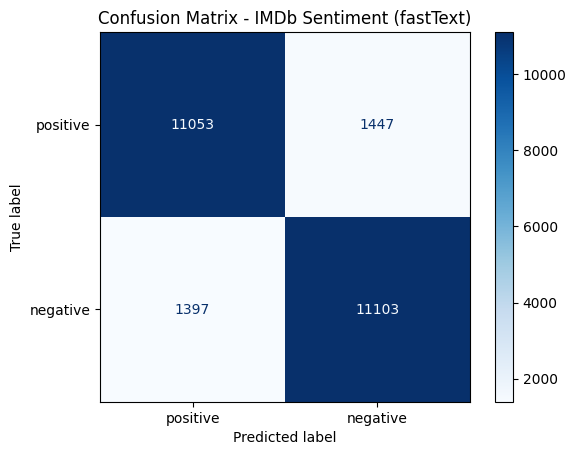

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ---------------------------------------------------
# Generate predictions on the complete test dataset
# ---------------------------------------------------
y_true = []
y_pred = []

with open(test_file, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        # Extract true label and review text
        if line.startswith("__label__positive"):
            true_label = "positive"
            text = line.replace("__label__positive", "", 1).strip()
        elif line.startswith("__label__negative"):
            true_label = "negative"
            text = line.replace("__label__negative", "", 1).strip()
        else:
            continue

        # ---------------------------------------------------
        # Use the lower-level fastText object to avoid NumPy 2.x issue
        # model.f.predict(...) returns (probabilities, labels)
        # ---------------------------------------------------
        prediction = model.f.predict(text, 1, 0.0, "strict")
        predicted_label = prediction[0][1].replace("__label__", "")

        y_true.append(true_label)
        y_pred.append(predicted_label)

# ---------------------------------------------------
# Compute confusion matrix
# ---------------------------------------------------
labels = ["positive", "negative"]
cm = confusion_matrix(y_true, y_pred, labels=labels)

# ---------------------------------------------------
# Display confusion matrix
# ---------------------------------------------------
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues, values_format="d")
plt.title("Confusion Matrix - IMDb Sentiment (fastText)")
plt.show()

# Step 12: Predict sentiment for new reviews

In [13]:
def safe_predict(model, text):
    prediction = model.f.predict(text, 1, 0.0, "strict")
    label = prediction[0][1].replace("__label__", "")
    probability = prediction[0][0]
    return label, probability

sample_reviews = [
    "This movie was brilliant, emotional, and beautifully acted.",
    "I found the film boring, predictable, and far too long.",
    "The story started slowly but became deeply engaging by the end."
]

for review in sample_reviews:
    label, probability = safe_predict(model, review)

    print("\nReview:", review)
    print("Predicted label :", label)
    print("Probability     :", round(probability, 4))


Review: This movie was brilliant, emotional, and beautifully acted.
Predicted label : positive
Probability     : 1.0

Review: I found the film boring, predictable, and far too long.
Predicted label : negative
Probability     : 1.0

Review: The story started slowly but became deeply engaging by the end.
Predicted label : negative
Probability     : 0.971


# Step 13: Convert labels into human-readable form

In [14]:
def predict_sentiment(review_text):
    prediction = model.f.predict(review_text, 1, 0.0, "strict")

    label = prediction[0][1].replace("__label__", "")
    probability = prediction[0][0]

    # Fix numerical instability
    probability = min(max(probability, 0.0), 1.0)

    return label, probability

examples = [
    "The acting was outstanding and the film was unforgettable.",
    "This was one of the worst movies I have ever seen."
]

for review in examples:
    label, prob = predict_sentiment(review)
    print("\nReview:", review)
    print("Sentiment:", label)
    print("Confidence:", prob)


Review: The acting was outstanding and the film was unforgettable.
Sentiment: negative
Confidence: 0.9065647721290588

Review: This was one of the worst movies I have ever seen.
Sentiment: negative
Confidence: 1.0


# Step 14: Inspect nearest neighbours of a sentiment-bearing word

In [15]:
for word in ["good", "bad"]:
    neighbors = model.get_nearest_neighbors(word)
    print(f"\nNearest neighbors of '{word}':")
    for score, neighbor in neighbors[:10]:
        print(f"{neighbor:>15} -> {score:.4f}")


Nearest neighbors of 'good':
    perfectness -> 0.9996
      perfected -> 0.9996
        perfect -> 0.9996
            job -> 0.9996
    excellently -> 0.9995
     perfecting -> 0.9995
  perfectionism -> 0.9995
     excellent' -> 0.9995
      excellent -> 0.9995
              7 -> 0.9995

Nearest neighbors of 'bad':
          badly -> 0.9999
          worst -> 0.9999
          avoid -> 0.9999
         boring -> 0.9999
         poorly -> 0.9999
          worse -> 0.9999
          awful -> 0.9999
           poor -> 0.9999
          waste -> 0.9999
         'worst -> 0.9999
